In [1]:
#scientific libraries and plotting
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn

#torch specific
import torch
import torchvision as torchv
import torch.optim as optim

#other libraries
import time
import sys
from pathlib import Path
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import atlas_mpl_style as ampl
from sklearn.metrics import log_loss as log_loss


In [2]:
# import custom functions from src folder
module_path = str(Path.cwd().parents[0] / "src")

if module_path not in sys.path:
    sys.path.append(module_path)

from machine_learning import *
from resnet import *
from resnet import ResNet18
from imcal import *
from imcal import Hdf5Dataset
from imcal import RandomRoll
from imcal import CircularPadding

In [3]:
#variables controlled by the user. Change these to fit your specific needs.

TRAIN_N_EVENTS = 10000 #Number of events to process for each class.
VAL_N_EVENTS = 3000 #Number of events to process for each class.
TEST_N_EVENTS = 15000 #Number of events to process for each class.
RES = 50 #resolution
CUT=True #Should cut be applied? Chooses different files if True.

#Data specification
LABELS = ["PP13-Sphaleron-THR9-FRZ15-NB0-NSUBPALL", "BH_n4_M8", "BH_n2_M10", "BH_n4_M10", "BH_n6_M10", "BH_n4_M12"]
TEST_LABELS = [f"{label}_test" for label in LABELS]
PLOT_LABELS = ["SPH_9", "BH_n4_M8", "BH_n2_M10", "BH_n4_M10", "BH_n6_M10", "BH_n4_M12"]
CLASSES = len(LABELS) #The number of output nodes in the net, equal to the number of classes
FOLDERS = ["sph", "BH", "BH", "BH", "BH", "BH"]


#Set data paths
if CUT:
    N_EVENTS = 10000
    TRAIN_FILENAMES = [f"{label}_res{RES}_STmin7_Nmin5_{N_EVENTS}_events.h5" for label in LABELS]
    TEST_FILENAMES = [f"{label}_res{RES}_STmin7_Nmin5_15000_events.h5" for label in TEST_LABELS]
    VAL_FILENAMES = [f"{label}_res{RES}_STmin7_Nmin5_3000_events.h5" for label in TEST_LABELS]
else:
    N_EVENTS = 10000
    TRAIN_FILENAMES = [f"{label}_res{RES}_{N_EVENTS}_events.h5" for label in LABELS]
    TEST_FILENAMES = [f"{label}_res{RES}_3000_events.h5" for label in TEST_LABELS]
    VAL_FILENAMES = [f"{label}_res{RES}_3000_events.h5" for label in TEST_LABELS]

TRAIN_DATAPATHS = [f"/disk/atlas3/data_MC/2dhistograms/{FOLDERS[i]}/{RES}/{TRAIN_FILENAMES[i]}" for i in range(CLASSES)]
VAL_DATAPATHS = [f"/disk/atlas3/data_MC/2dhistograms/{FOLDERS[i]}/{RES}/{VAL_FILENAMES[i]}" for i in range(CLASSES)]
TEST_DATAPATHS = [f"/disk/atlas3/data_MC/2dhistograms/{FOLDERS[i]}/{RES}/{TEST_FILENAMES[i]}" for i in range(CLASSES)]

#Set a unique name for the model
labelstring = '_'.join([str(elem) for elem in PLOT_LABELS])
if CUT:
    MODEL_NAME = f"resnet_{str(int(time.time()))}_{labelstring}_CUT_res{RES}"
else: MODEL_NAME = f"resnet_{str(int(time.time()))}_{labelstring}"
print(MODEL_NAME)
#Where to save the model
SAVE_FOLDER = "../results/models"
SAVE_PATH = f"{SAVE_FOLDER}/{MODEL_NAME}.pt"

#Setup GPU if available
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.cuda.empty_cache()
    print("Running on the GPU")
else:
    DEVICE = torch.device("cpu")
    print("Running on the CPU")

#Data processing
#filters=["saturate"]
transforms = torch.nn.Sequential(torchv.transforms.RandomVerticalFlip(),RandomRoll(roll_axis=0))
#transforms = None
#For plotting
ampl.use_atlas_style()   

resnet_1758700165_SPH_9_BH_n4_M8_BH_n2_M10_BH_n4_M10_BH_n6_M10_BH_n4_M12_CUT_res50
Running on the GPU


### Load data

In [4]:
#Load data

testpaths = [Path(path) for path in TEST_DATAPATHS]
trainpaths = [Path(path) for path in TRAIN_DATAPATHS]
valpaths = [Path(path) for path in VAL_DATAPATHS]

"""#Load lazily to save memory
test_data = Hdf5Dataset(testpaths, TEST_LABELS, DEVICE, 
                        shuffle=False, filters=filters, transform=None, event_limit=TEST_N_EVENTS)
val_data = Hdf5Dataset(valpaths, TEST_LABELS, DEVICE, 
                        shuffle=True, filters=filters, transform=None, event_limit=VAL_N_EVENTS)
train_data = Hdf5Dataset(trainpaths, LABELS, DEVICE, 
                        shuffle=True, filters=filters, transform=transforms, event_limit=TRAIN_N_EVENTS)
"""
#Load directly to speed up
train_data = load_datasets(trainpaths, DEVICE, TRAIN_N_EVENTS, filters, transforms=transforms)
test_data = load_datasets(testpaths, DEVICE, TEST_N_EVENTS, filters, transforms=None)
val_data = load_datasets(valpaths, DEVICE, VAL_N_EVENTS, filters, transforms=None)


Loads data with transforms Sequential(
  (0): RandomVerticalFlip(p=0.5)
  (1): RandomRoll()
) and filters [None]
Loaded data with 10000 entries of shape (10000, 50, 50, 3).
Check max value: 15630.7041015625.
Check max value: 15630.7041015625.
Loaded data with 10000 entries of shape (10000, 50, 50, 3).
Check max value: 18992.416015625.
Check max value: 18992.416015625.
Loaded data with 10000 entries of shape (10000, 50, 50, 3).
Check max value: 31096.15625.
Check max value: 31096.15625.
Loaded data with 10000 entries of shape (10000, 50, 50, 3).
Check max value: 24906.041015625.
Check max value: 24906.041015625.
Loaded data with 10000 entries of shape (10000, 50, 50, 3).
Check max value: 24746.404296875.
Check max value: 24746.404296875.
Loaded data with 10000 entries of shape (10000, 50, 50, 3).
Check max value: 31944.91796875.
Check max value: 31944.91796875.
Data has shape torch.Size([50, 50, 3])
There are 6 classes.
Loads data with transforms None and filters [None]
Loaded data with

In [5]:
print(val_data[0][0].shape)

torch.Size([50, 50, 3])


### View the data

Opening file /disk/atlas3/data_MC/2dhistograms/sph/50/PP13-Sphaleron-THR9-FRZ15-NB0-NSUBPALL_res50_STmin7_Nmin5_10000_events.h5.
Selecting 1000 events out of 10000.
Opening file /disk/atlas3/data_MC/2dhistograms/BH/50/BH_n4_M8_res50_STmin7_Nmin5_10000_events.h5.
Selecting 1000 events out of 10000.
Opening file /disk/atlas3/data_MC/2dhistograms/BH/50/BH_n2_M10_res50_STmin7_Nmin5_10000_events.h5.
Selecting 1000 events out of 10000.
Opening file /disk/atlas3/data_MC/2dhistograms/BH/50/BH_n4_M10_res50_STmin7_Nmin5_10000_events.h5.
Selecting 1000 events out of 10000.
Opening file /disk/atlas3/data_MC/2dhistograms/BH/50/BH_n6_M10_res50_STmin7_Nmin5_10000_events.h5.
Selecting 1000 events out of 10000.
Opening file /disk/atlas3/data_MC/2dhistograms/BH/50/BH_n4_M12_res50_STmin7_Nmin5_10000_events.h5.
Selecting 1000 events out of 10000.


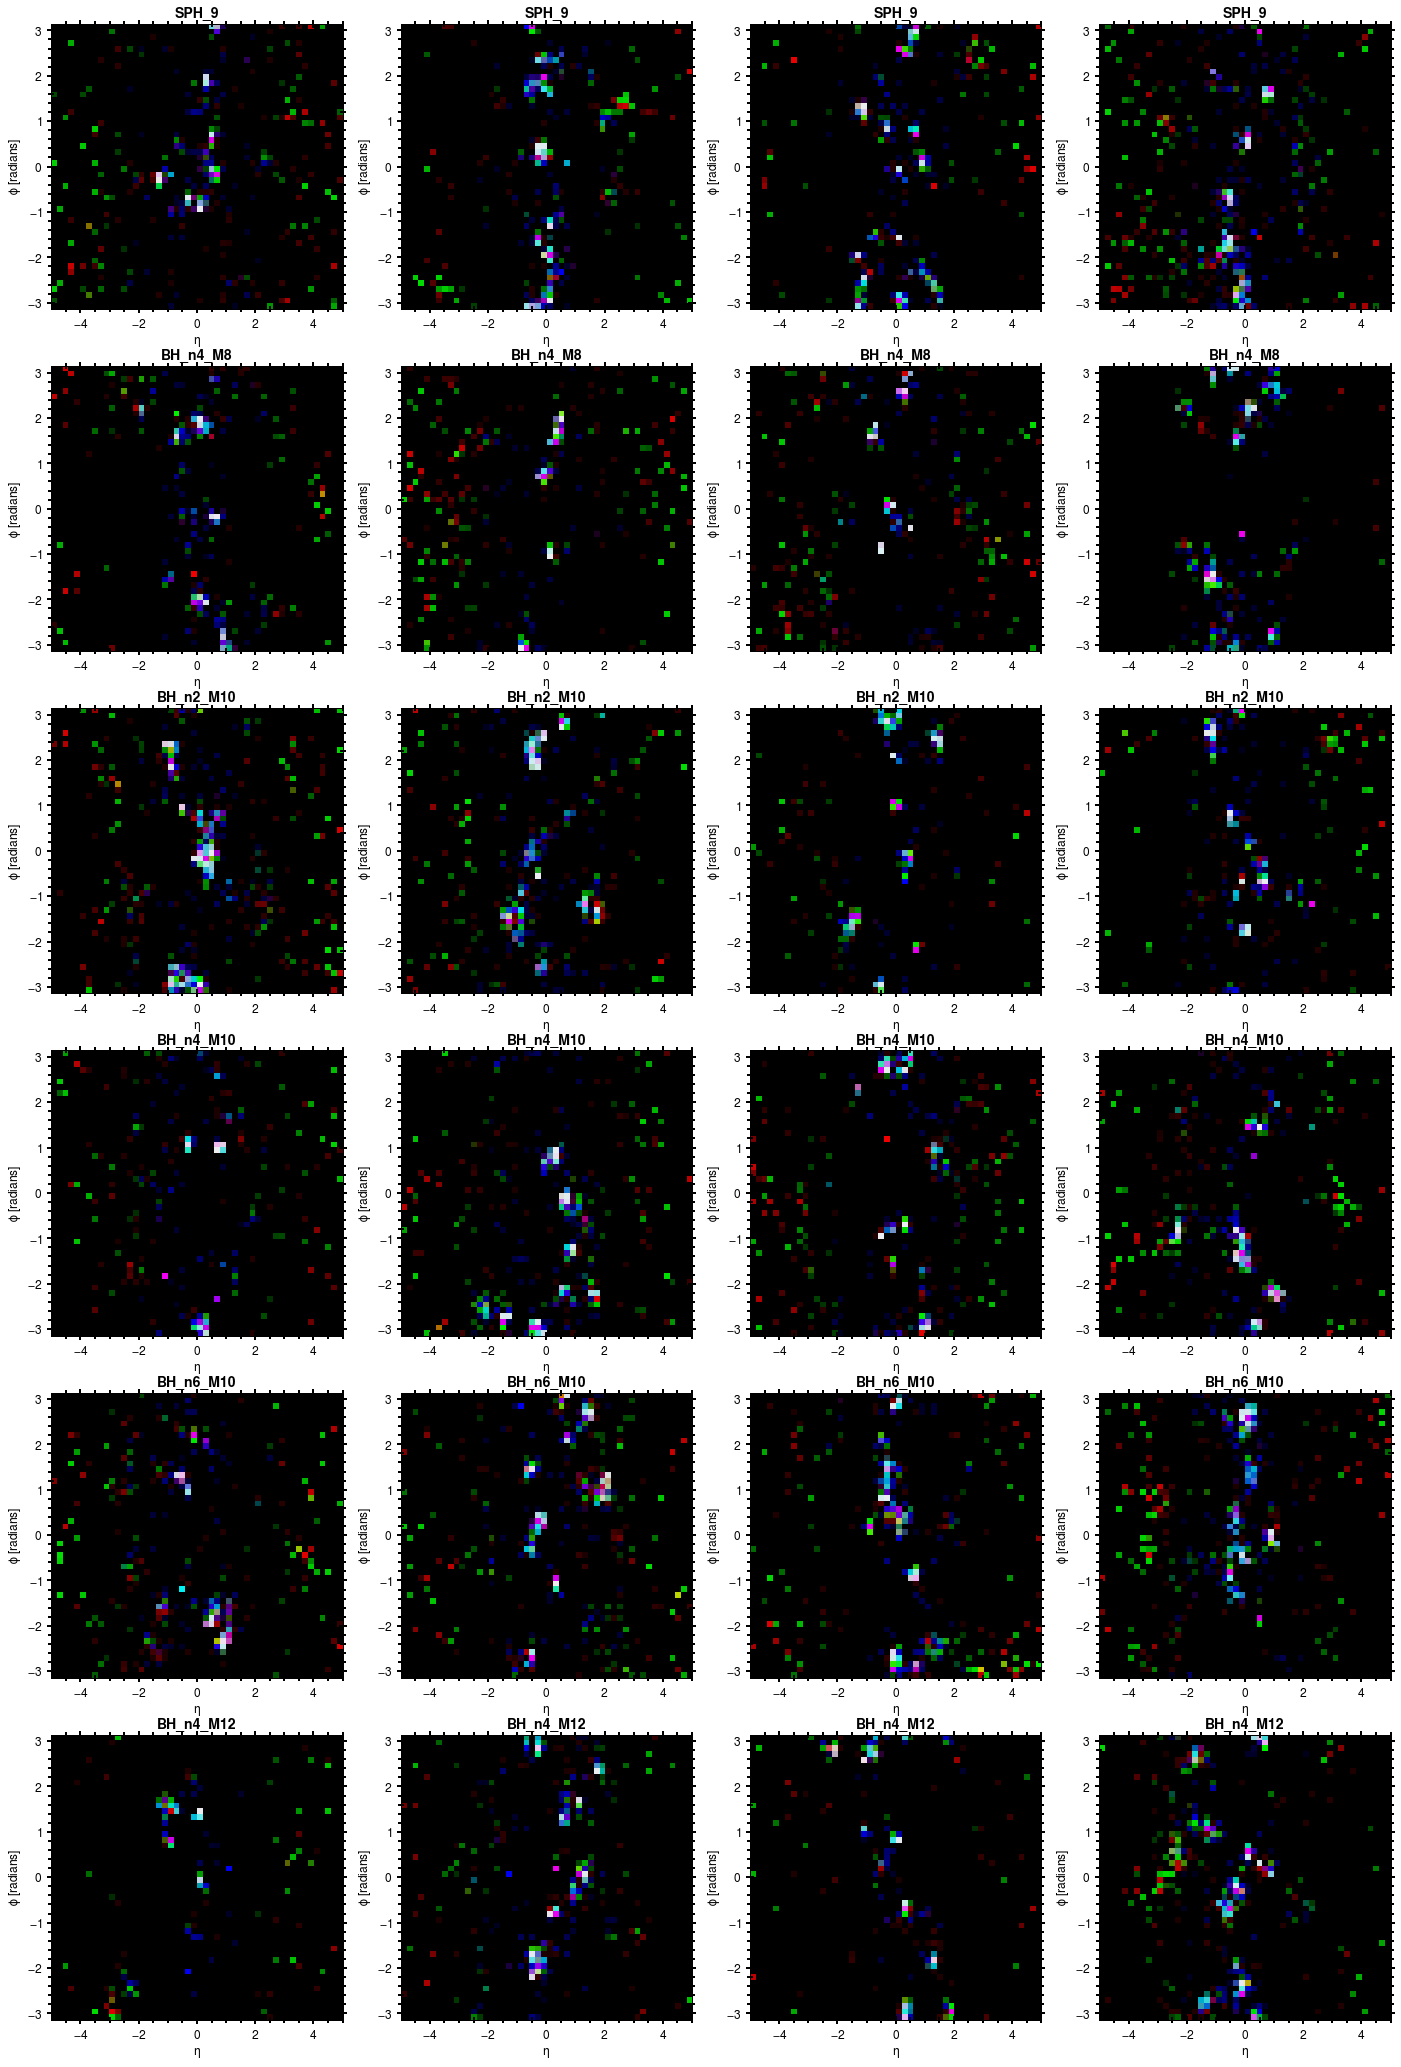

In [6]:
#Print some of the images
inspect_data = Hdf5Dataset(trainpaths, LABELS, DEVICE, max_value=70, 
                        shuffle=False, filters=["paper"], transform=None, event_limit=1000)
view_data(inspect_data, 4, CLASSES, PLOT_LABELS, RES, 1000)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Look at the highest histogram values values for a random image
[ 552.91296  566.23145  580.26935  626.0841   663.9828   900.68854
 1016.946   1266.3958  2144.016  ]
Looking at image 0


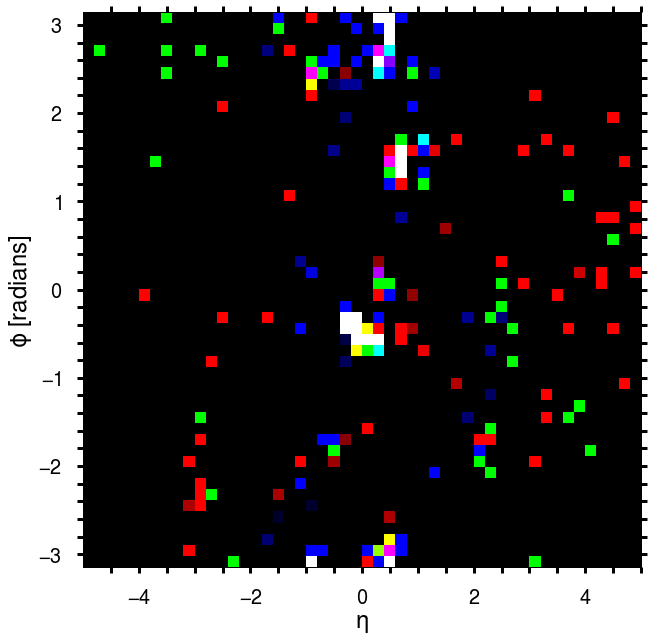

In [7]:
#Look at an image more closely
image = val_data[-1][0].cpu()
print("Look at the highest histogram values values for a random image")
print(np.sort(image.flatten())[-10:-1])
print("Looking at image", 0)

fig, ax = plt.subplots(ncols=1, figsize=(10, 10))
ax.imshow(image, extent=[-5, 5, -np.pi, np.pi], aspect='auto')
cal_image_plot_paper(ax)
ax.tick_params(which="both", direction="out", bottom=True, left=True, labelsize=20, pad=15, length=6, width=3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


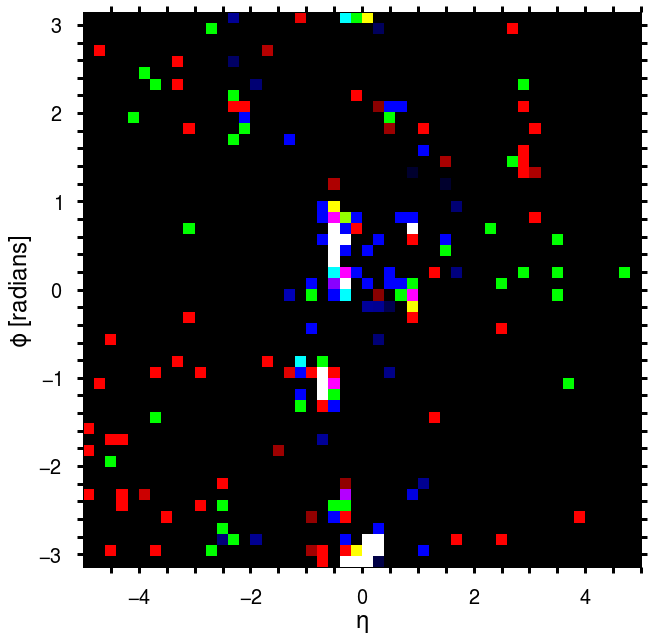

In [8]:
#Check augmentation on the same image
if transforms!=None:
    fig, ax = plt.subplots(ncols=1, figsize=(10, 10))
    rolled_image = transforms(image)
    ax.imshow(rolled_image, extent=[-5, 5, -np.pi, np.pi], aspect='auto')
    cal_image_plot_paper(ax)
    ax.tick_params(which="both", direction="out", bottom=True, left=True, labelsize=20, pad=15, length=6, width=3)

### Create net and train

In [29]:
#Create NN.
resnet = ResNet18(img_channels=3, num_classes=CLASSES)
resnet.to(DEVICE)
#Test that nothing major is wrong.
testimage, testlabel = val_data[0][0], val_data[0][1]
print(testimage.shape)
testimage = torch.swapaxes(testimage, -3, -1)
print(testimage.shape)
print(-1, 3, testimage.shape[-2], testimage.shape[-1])
print(resnet(testimage.view(-1, 3, testimage.shape[-2], testimage.shape[-1]).to(DEVICE)))
print(testlabel)
#Set optimizer, learning rate scheduler and train the model
batchsize = 256
max_epochs = 100
base_lr = 0.001
optimizer = optim.Adam(resnet.parameters(), lr=base_lr)
halfperiod = 5#int(TRAIN_N_EVENTS*6/batchsize)
#scheduler = optim.lr_scheduler.CyclicLR(optimizer, 0.0001, 0.01, cycle_momentum=False)
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=base_lr, max_lr=base_lr*10, step_size_up=halfperiod, mode="exp_range", gamma=0.85, cycle_momentum=False)
training_results = train_classifier(resnet, train_data, val_data, batchsize, max_epochs, DEVICE, optimizer, scheduler, early_stopping=10, val_batchsize=1024)

torch.Size([50, 50, 3])
torch.Size([3, 50, 50])
-1 3 50 50
tensor([[-0.3148, -0.3040, -0.4292,  0.3490, -0.5576, -0.1463]],
       device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([1., 0., 0., 0., 0., 0.], device='cuda:0')
Stopping training early at epoch 61


In [30]:
training_results["Epoch"].values[-1] + 1

62

In [31]:
#Test that nothing major is wrong after training.
k = np.random.randint(0, len(val_data))
testimage, testlabel = val_data[k][0], val_data[k][1]
testimage = torch.swapaxes(testimage, -3, -1)
print(testimage.view(-1, 3, testimage.shape[-2], testimage.shape[-1]).shape)
print(resnet(testimage.view(-1, 3, testimage.shape[-2], testimage.shape[-1]).to(DEVICE)), testlabel)

torch.Size([1, 3, 50, 50])
tensor([[-10.6324,  -3.8041,   0.6711,   0.3827,   0.5082,  -4.9916]],
       device='cuda:0', grad_fn=<AddmmBackward0>) tensor([0., 0., 0., 1., 0., 0.], device='cuda:0')


### Inspect the results

Text(0, 0.5, 'Accuracy')

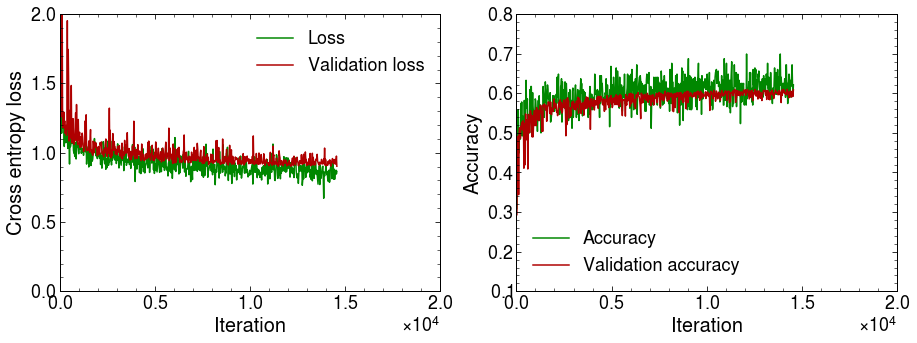

In [32]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))
training_results.plot("Iteration", ["Loss", "Validation loss"], ax=axs[0])
training_results.plot("Iteration", ["Accuracy", "Validation accuracy"], ax=axs[1])
axs[0].set_ylim(0, 2)
axs[0].set_xlim(0)
axs[0].set_ylabel("Cross entropy loss")
axs[1].set_ylim(0.1, 0.8)
axs[1].set_xlim(0)
axs[1].set_ylabel("Accuracy")

In [33]:
training_results

,Loss,Accuracy,Validation loss,Validation accuracy,Epoch,Iteration
0,1.620052,0.308594,1.729349,0.293529,0,23
1,1.388250,0.406250,1.407754,0.409111,0,46
2,1.357308,0.421875,1.750605,0.366209,0,69
3,1.140597,0.558594,1.260072,0.491638,0,92
4,1.301328,0.453125,2.226557,0.344029,0,115
...,...,...,...,...,...,...
628,0.855463,0.644531,0.951734,0.590366,61,14467
629,0.844854,0.671875,0.920768,0.604985,61,14490
630,0.874260,0.621094,0.916574,0.601963,61,14513
631,0.847107,0.593750,0.975577,0.592199,61,14536


### Predict on test set and check accuracy

In [34]:
truth, logits = predict_classifier(resnet, test_data, CLASSES, 100, DEVICE)
confidences = torch.softmax(logits, dim=-1)

In [35]:
df_test = pd.DataFrame(columns=["Truth", "Prediction"])
df_test["Truth"] = truth
df_test["Confidence"], df_test["Prediction"] = torch.max(confidences, axis=-1)
for j in range(len(PLOT_LABELS)):
    df_test[f"{j}"] = confidences[:,j]
correct_list = np.array([True]*len(df_test))
correct_list[df_test["Prediction"] != df_test["Truth"]] = False
df_test["Correct"] = correct_list

In [36]:
accuracy = accuracy_score(df_test["Truth"], df_test["Prediction"], normalize=True)
print("Global accuracy: ", accuracy)
logloss = log_loss(df_test["Truth"], df_test[[f"{j}" for j in range(len(LABELS))]], normalize=True)
print("Log loss: ", logloss)

Global accuracy:  0.5787333333333333
Log loss:  1.0214331093219655


In [37]:
#Save model
#torch.save(resnet.state_dict(), SAVE_PATH)

[0.932 0.053 0.011 0.002 0.001 0.001 0.1   0.808 0.038 0.015 0.032 0.007
 0.101 0.154 0.401 0.092 0.201 0.051 0.051 0.186 0.287 0.101 0.322 0.053
 0.04  0.21  0.237 0.1   0.362 0.052 0.008 0.015 0.04  0.019 0.05  0.869]


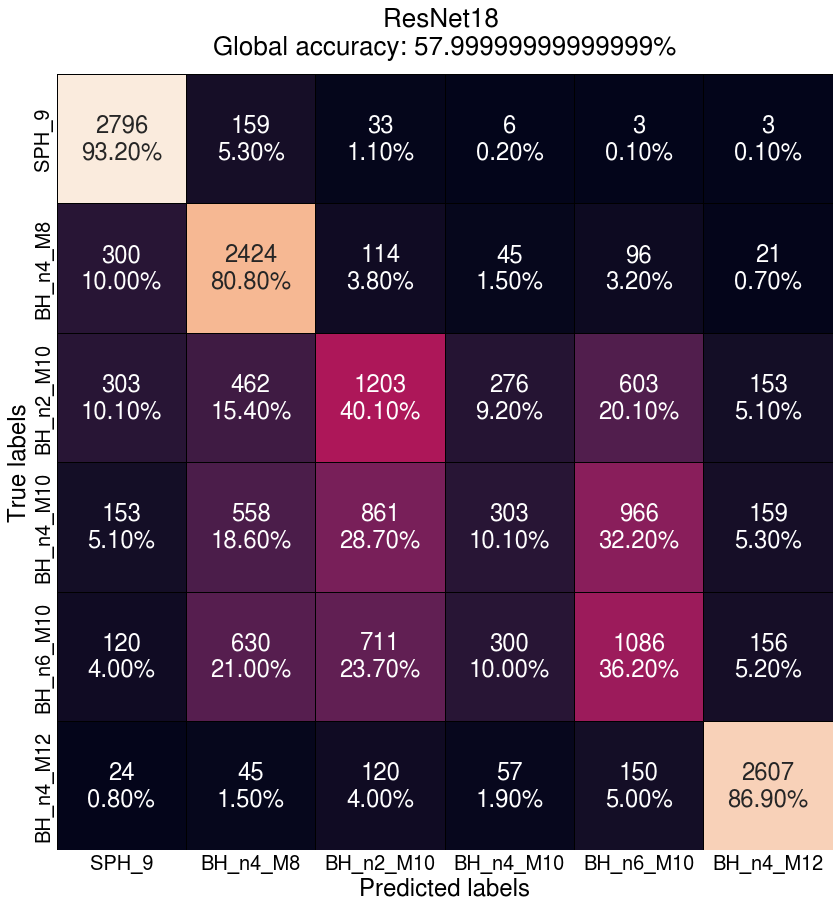

In [38]:
def plot_conf_matrix(df, accuracy, labels):
    """
    plot confusion matrix
    """
    fig, ax = plt.subplots(1,1, figsize=(14, 14))

    #Generate the confusion matrix
    cf_matrix = confusion_matrix(df["Truth"], df["Prediction"], normalize="true")
    cf_matrix = np.round(cf_matrix, 3)
    print(cf_matrix.flatten())
    group_counts = ["{0:0.0f}".format(value*VAL_N_EVENTS) for value in cf_matrix.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cf_matrix.flatten()]
    annot = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
    annot = np.asarray(annot).reshape(len(labels),len(labels))
    sn.heatmap(
            cf_matrix, 
            ax=ax, 
            annot=annot, 
            cmap='rocket', 
            linewidths=1.0, 
            linecolor='black',
            cbar = False, 
            square=True, 
            fmt='', 
            cbar_kws={'format':'%.0f'},
            annot_kws={"size": 24}
        )

    #ax.set_title('Confusion matrix\n\n', size=24)
    ax.set_xlabel('Predicted labels', size=24)
    ax.set_ylabel('True labels', size=24)

    ## Ticket labels - List must be in alphabetical order
    ax.xaxis.set_ticklabels(labels, size=20)
    ax.yaxis.set_ticklabels(labels, size=20)
    ax.tick_params(which="both", left=False, bottom=False, top=False, right=False)
    ax.set_title(f"ResNet18 \nGlobal accuracy: {round(accuracy, 2)*100}%", size=26, pad=20)

    ## Display the visualization of the Confusion Matrix.
    plt.show()
plot_conf_matrix(df_test, accuracy, PLOT_LABELS)